# ViT (SegFormer) — границы полей + YOLO26

Agriculture-Vision, метрики ТЗ §5.1, экспорт GeoJSON.

Перед запуском: `pip install -r requirements.txt` и `python scripts/download_agvision.py --extract`

**После обновления кода:** Kernel → Restart Kernel and Run All.

In [1]:
%load_ext autoreload
%autoreload 2

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = Path.cwd().resolve()
if not (ROOT / 'field_detecter').is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from field_detecter.config_loader import load_config
from field_detecter.agvision_dataset import AgVisionDataset, discover_split_root
from field_detecter import agvision_dataset as _av
print('agvision_dataset:', _av.__file__)

CONFIG_PATH = ROOT / 'config' / 'agvision.yaml'
cfg = load_config(CONFIG_PATH)
DATA_ROOT = ROOT / cfg['data']['root']
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('ROOT:', ROOT)
print('Device:', device)
print('Data root:', DATA_ROOT)

agvision_dataset: /home/eq/techlb/field_detecter/field_detecter/agvision_dataset.py
ROOT: /home/eq/techlb/field_detecter
Device: cuda
Data root: /home/eq/techlb/field_detecter/data/agvision


## 1. Проверка данных

split: /home/eq/techlb/field_detecter/data/agvision/Agriculture-Vision-2021/train
stem: 11IE4DKTR_11556-9586-12068-10098
boundary pixels: 136816, valid: 262144


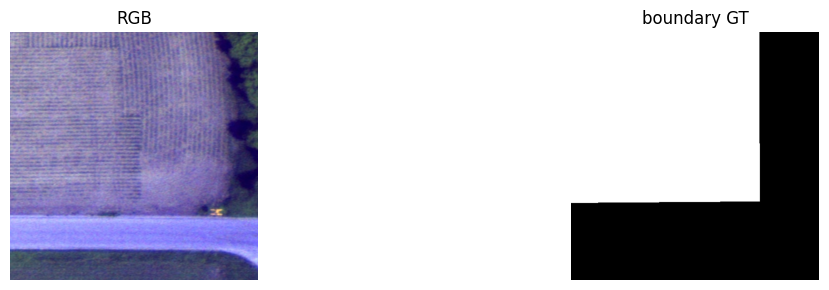

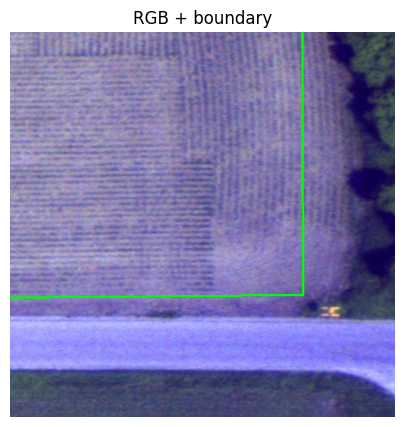

In [2]:
version_dir = cfg['data'].get('version_dir', 'Agriculture-Vision-2021')
split_root = discover_split_root(DATA_ROOT, version_dir, 'train')
ds = AgVisionDataset(DATA_ROOT, 'train', version_dir=version_dir, max_samples=4)
sample = ds[0]
print(f'split: {split_root}')
print(f'stem: {sample["stem"]}')
print(f'boundary pixels: {sample["boundary"].sum()}, valid: {sample["valid_mask"].sum()}')
assert sample['boundary'].sum() > 0, 'boundary пустая — перезапустите kernel (Restart)'

fig, ax = plt.subplots(1, 2, figsize=(14, 3))
rgb = np.stack([sample['image'][1], sample['image'][2], sample['image'][3]], axis=-1)
ax[0].imshow(rgb); ax[0].set_title('RGB')
ax[1].imshow(sample['boundary'], cmap='gray', vmin=0, vmax=1); ax[1].set_title('boundary GT')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(rgb)
ax.contour(sample['boundary'], colors='lime', linewidths=0.8)
ax.set_title('RGB + boundary'); ax.axis('off'); plt.show()

## 2. Обучение SegFormer

In [ ]:
from field_detecter.train_seg import train

# Ночной прогон: 4ch NIR+RGB, шум/blur, rgb_dropout → опора на NIR
# cfg['segmentation']['resume'] = False  # True — продолжить best_iou.pth
best_ckpt = train(cfg, data_root=DATA_ROOT)
print('Checkpoint:', best_ckpt)

/home/eq/.conda/envs/ML/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Train augmentations: NIR+RGB, noise/blur, rgb_dropout for NIR reliance
Backup: /home/eq/techlb/field_detecter/outputs/segformer/best_iou_backup.pth


Loading weights:   0%|          | 0/930 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b4-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([2])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([2, 768, 1, 1])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


gradient_checkpointing enabled
Train tiles: 56944, val tiles: 1000, epochs 1-40


...

epoch 21/40: 100%|██████████| 5177/5177 [1:12:33<00:00,  1.19it/s]


epoch 21: loss=0.1465 lr=2.63e-05 val_iou=0.9436 P=0.9483 R=0.9915


epoch 22/40: 100%|██████████| 5177/5177 [1:12:33<00:00,  1.19it/s]


epoch 22: loss=0.1447 lr=2.44e-05 val_iou=0.9426 P=0.9487 R=0.9896
Early stop: no IoU improvement for 10 epochs


val:  45%|████▌     | 4141/9167 [33:35<3:16:29,  2.35s/it]

## 3. Метрики ТЗ

In [1]:
report_path = ROOT / cfg['metrics']['report_path']
if report_path.exists():
    print(json.dumps(json.loads(report_path.read_text(encoding='utf-8')), indent=2, ensure_ascii=False))
else:
    print('Сначала обучите SegFormer')

NameError: name 'ROOT' is not defined

## 4. YOLO26 (pseudo tree/pole)

In [ ]:
from field_detecter.pseudo_points import export_yolo_dataset
from field_detecter.train_det import train_yolo
export_yolo_dataset(cfg, data_root=DATA_ROOT)
best_det = train_yolo(cfg)
print('YOLO:', best_det)

## 5. GeoJSON экспорт

In [ ]:
from field_detecter.polygon import mask_to_navigable_polygon, polygon_to_geojson_feature
from field_detecter.train_seg import Segformer4ChWrapper
from field_detecter.agvision_dataset import collate_segformer_batch
import torch.nn.functional as F

ckpt_path = ROOT / cfg['segmentation']['output_dir'] / 'best_iou.pth'
val_ds = AgVisionDataset(DATA_ROOT, 'val', version_dir=version_dir, max_samples=1)
batch = collate_segformer_batch([val_ds[0]])
model = Segformer4ChWrapper(cfg['segmentation']['model_id']).to(device)
model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=False)['model_state'])
model.eval()
with torch.no_grad():
    x = batch['pixel_values'].to(device)
    logits = model(x).logits
    if logits.shape[-2:] != x.shape[-2:]:
        logits = F.interpolate(logits, size=x.shape[-2:], mode='bilinear', align_corners=False)
    pred = (logits.softmax(1)[:, 1] >= 0.5).cpu().numpy()[0].astype(np.uint8)
nav = mask_to_navigable_polygon(pred)
feat = polygon_to_geojson_feature(nav['polygon_px'], origin_lat=52.0, origin_lon=23.7)
out_geo = ROOT / 'outputs' / 'field_polygon.geojson'
out_geo.parent.mkdir(parents=True, exist_ok=True)
out_geo.write_text(json.dumps({'type': 'FeatureCollection', 'features': [feat]}, indent=2), encoding='utf-8')
print('Saved', out_geo)